In [84]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [85]:
#Load preprocessed data
X_train = np.load('data/processed/X_train.npy')
X_test = np.load('data/processed/X_test.npy')
y_train = np.load('data/processed/y_train.npy')
y_test = np.load('data/processed/y_test.npy')

#Model Training to involve
##BatchNorm: 
Normalizes activations inside the network.
Benefits:
- stabilizes training
- faster convergence
- allows higher learning rates
- reduces internal covariate shift

##Dropout:
- random neurons disabled
- prevents overfitting

In [86]:
#Model Training
model = Sequential([
    Dense(64, activation='relu',
          input_dim=X_train.shape[1]),
    #BatchNormalization(),
    Dropout(0.3),
    # Dense(128, activation='relu'),
    # BatchNormalization(),
    # Dropout(0.3),
    # Dense(64, activation='relu'),
    # BatchNormalization(),
    # Dropout(0.3),
    Dense(32, activation='relu'),
    #BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [88]:
early_stop = EarlyStopping(
    monitor='val_loss',

    patience=7,

    restore_best_weights=True
)

In [89]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',

    factor=0.5,

    patience=3
)

##Batches Matter

Benefits:
- lower memory usage
- smoother gradients
- faster convergence
- GPU efficiency

In [90]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[
        early_stop #,
        #reduce_lr
    ]
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6664 - loss: 0.6571 - precision: 0.4169 - recall: 0.6209 - val_accuracy: 0.7947 - val_loss: 0.4374 - val_precision: 0.5822 - val_recall: 0.7397
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7209 - loss: 0.5978 - precision: 0.4818 - recall: 0.5835 - val_accuracy: 0.8018 - val_loss: 0.4329 - val_precision: 0.6109 - val_recall: 0.6507
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7431 - loss: 0.5649 - precision: 0.5197 - recall: 0.5154 - val_accuracy: 0.8053 - val_loss: 0.4124 - val_precision: 0.6388 - val_recall: 0.5753
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7747 - loss: 0.4856 - precision: 0.5938 - recall: 0.4971 - val_accuracy: 0.8089 - val_loss: 0.4107 - val_precision: 0.6390 - val_recall: 0.6062
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7782 - loss: 0.4660 - precision: 0.6058 - recall: 0.4879 - val_accuracy: 0.8053 - val_lo

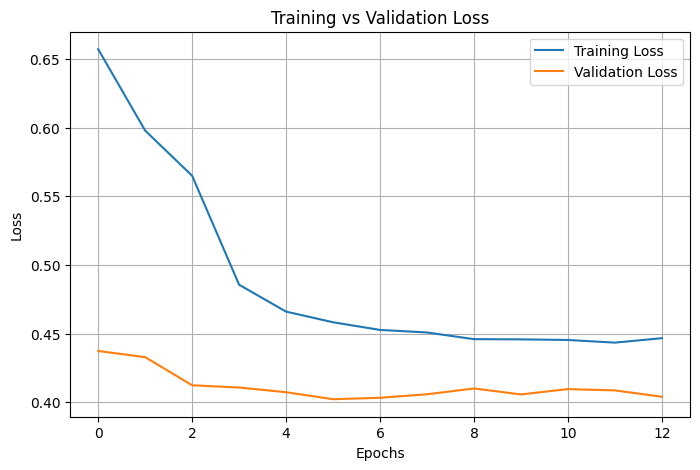

In [95]:
#Training vs Validation Loss
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.grid(True)

plt.show()

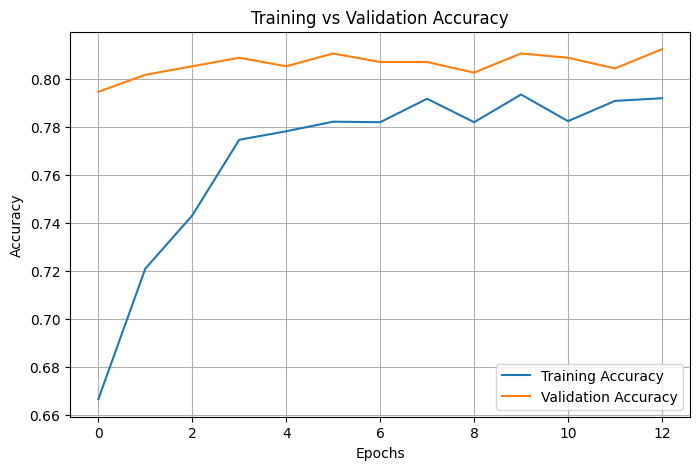

In [96]:
#Validation Accuracy
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()

plt.grid(True)

plt.show()

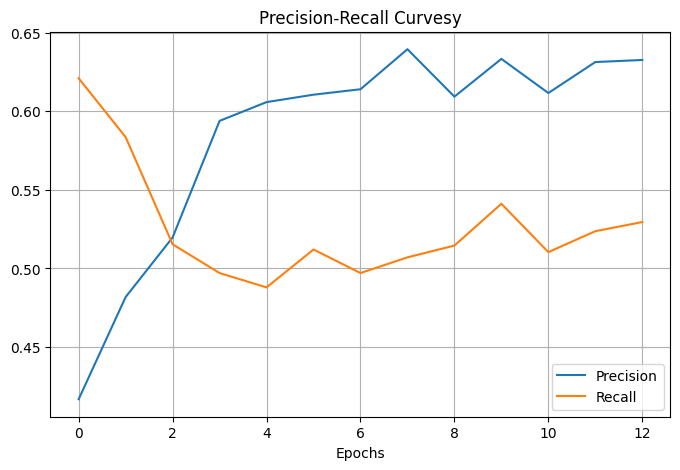

In [ ]:
#Precision/Recall Curves
plt.figure(figsize=(8,5))
plt.plot(
    history.history['precision'],
    label='Precision'
)
plt.plot(
    history.history['recall'],
    label='Recall'
)
plt.xlabel('Epochs')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

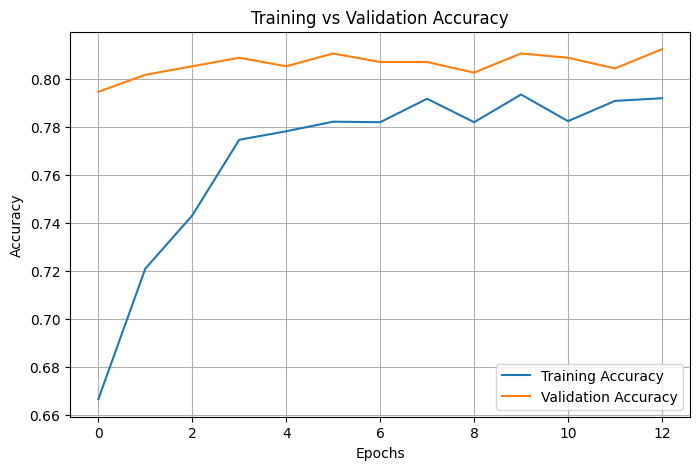